In [1]:
old_wd <- getwd()

setwd("../../")

if (file.exists("renv/activate.R")) {
  source("renv/activate.R")
} else {
  stop("Could not find renv/activate.R in project root")
}

setwd(old_wd)

- The project is out-of-sync -- use `renv::status()` for details.


In [2]:
library(fda)

Loading required package: splines

Loading required package: fds

Loading required package: rainbow

Loading required package: MASS

Loading required package: pcaPP

Loading required package: RCurl

Loading required package: deSolve

Warning message:
“package ‘deSolve’ was built under R version 4.5.2”

Attaching package: ‘fda’


The following object is masked from ‘package:graphics’:

    matplot


The following object is masked from ‘package:datasets’:

    gait




In [ ]:
#  display the data files associated with the fda package
data(package='fda')

Data sets in package ‘fda’:

CanadianWeather         Canadian average annual weather cycle
MontrealTemp            Montreal Daily Temperature
ReginaPrecip            Regina Daily Precipitation
daily                   Canadian average annual weather cycle
day.5 (dateAccessories)
                        Numeric and character vectors to facilitate
                        working with dates
dayOfYear (dateAccessories)
                        Numeric and character vectors to facilitate
                        working with dates
dayOfYearShifted (dateAccessories)
                        Numeric and character vectors to facilitate
                        working with dates
daysPerMonth (dateAccessories)
                        Numeric and character vectors to facilitate
                        working with dates
gait                    Hip and knee angle while walking
growth                  Berkeley Growth Study data
handwrit                Cursive handwriting samples
handwritTime (handwrit)

##
## Section 3.1 Basis Function Systems for Constructing Functions
##

In [5]:
unitRng = c(0,1)
unitRng

[1] 0 1

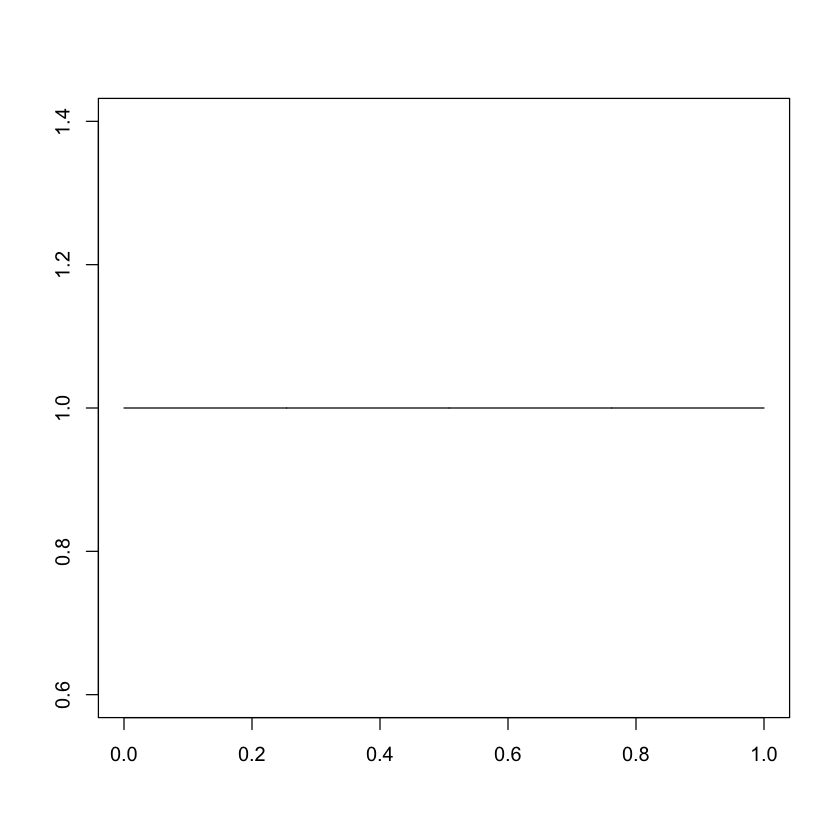

In [6]:
const.basis   = create.constant.basis(unitRng)
plot(const.basis)

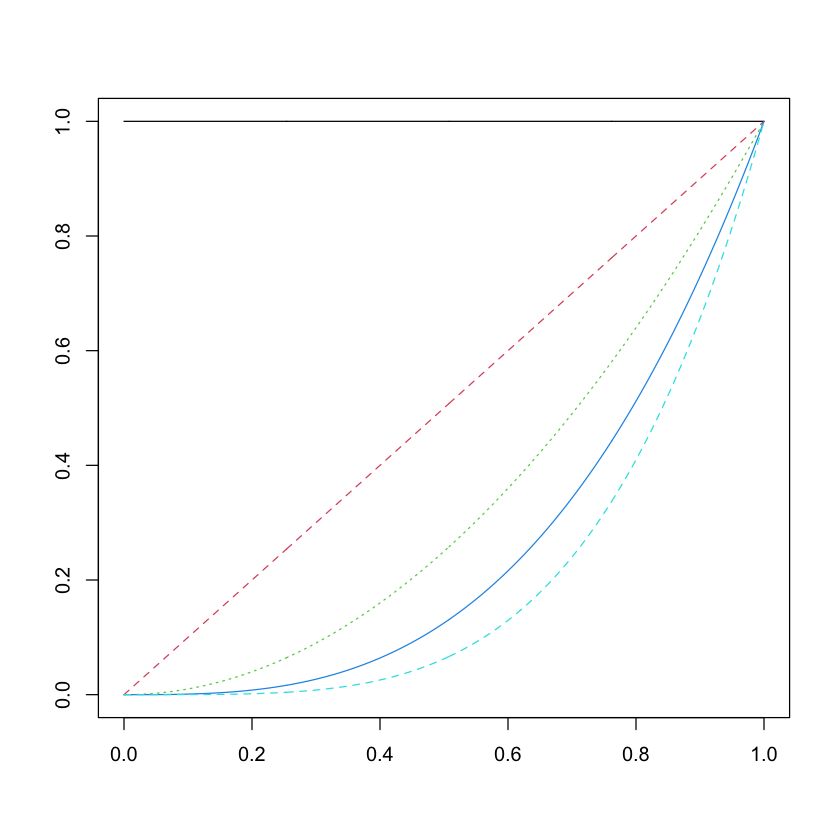

In [7]:
monom.basis   = create.monomial.basis(unitRng, nbasis=5)
plot(monom.basis)

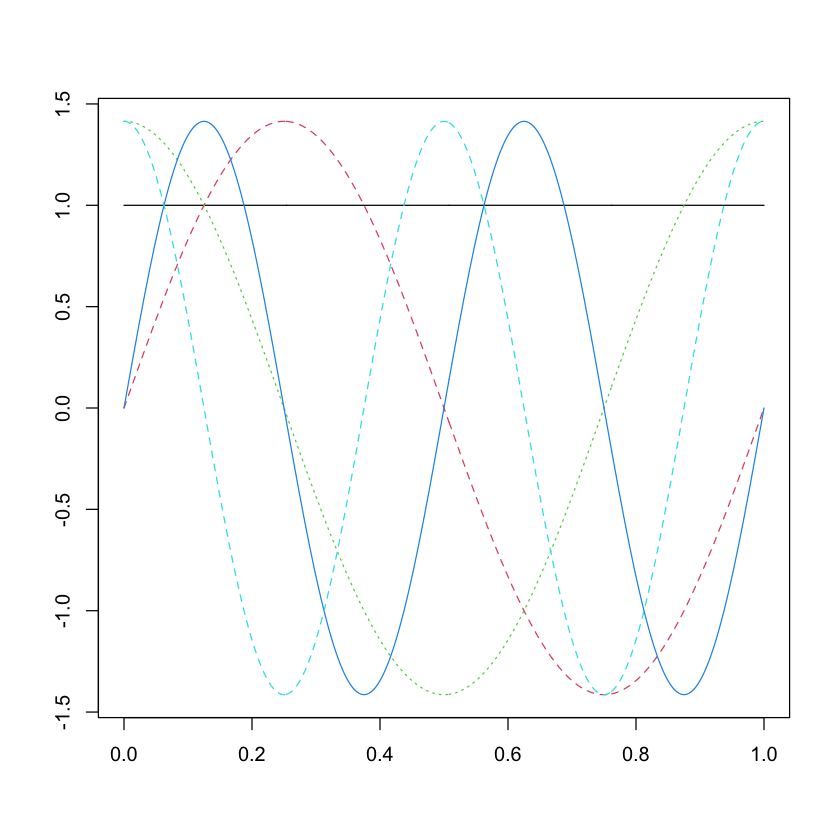

In [8]:
fourier.basis = create.fourier.basis(unitRng, nbasis=5, period=1)
plot(fourier.basis)

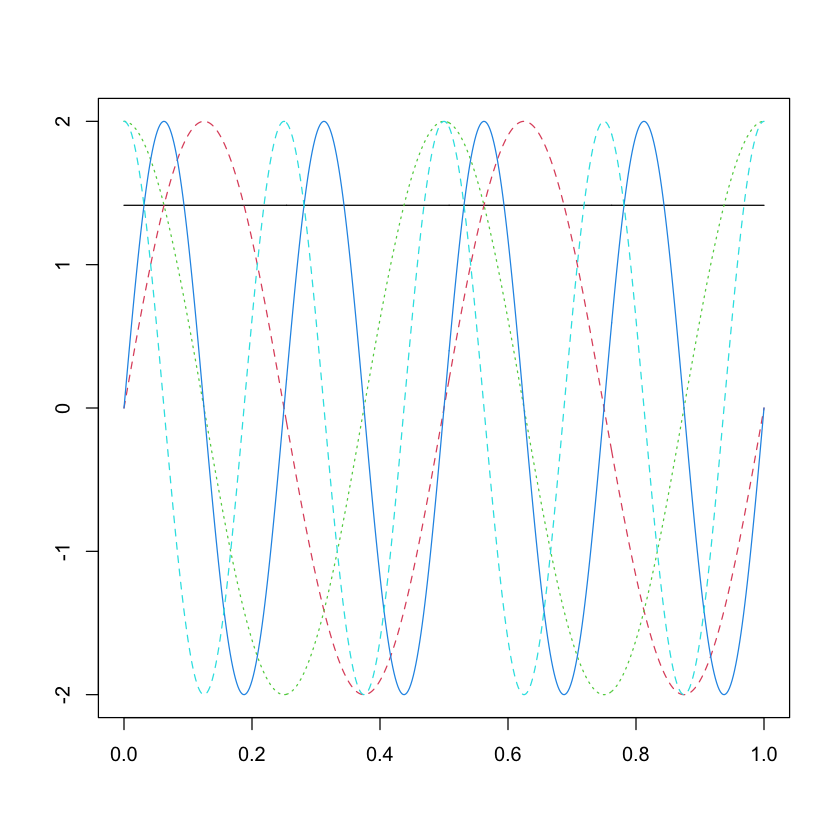

In [9]:
fourier.basis = create.fourier.basis(unitRng, nbasis=5, period=0.5)
plot(fourier.basis)

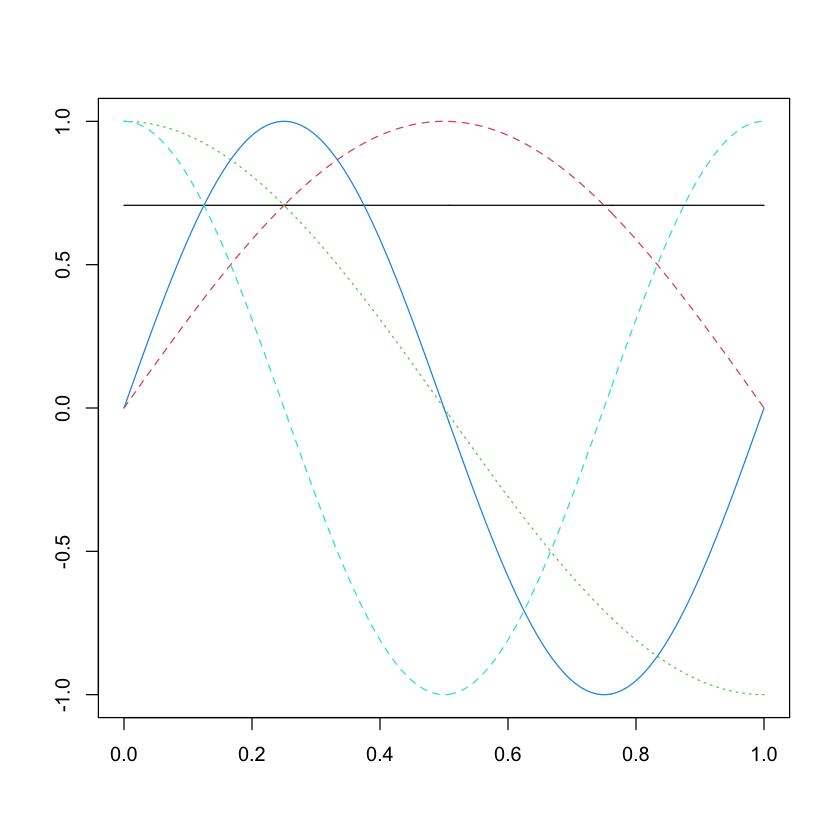

In [10]:
fourier.basis = create.fourier.basis(unitRng, nbasis=5, period=2)
plot(fourier.basis)

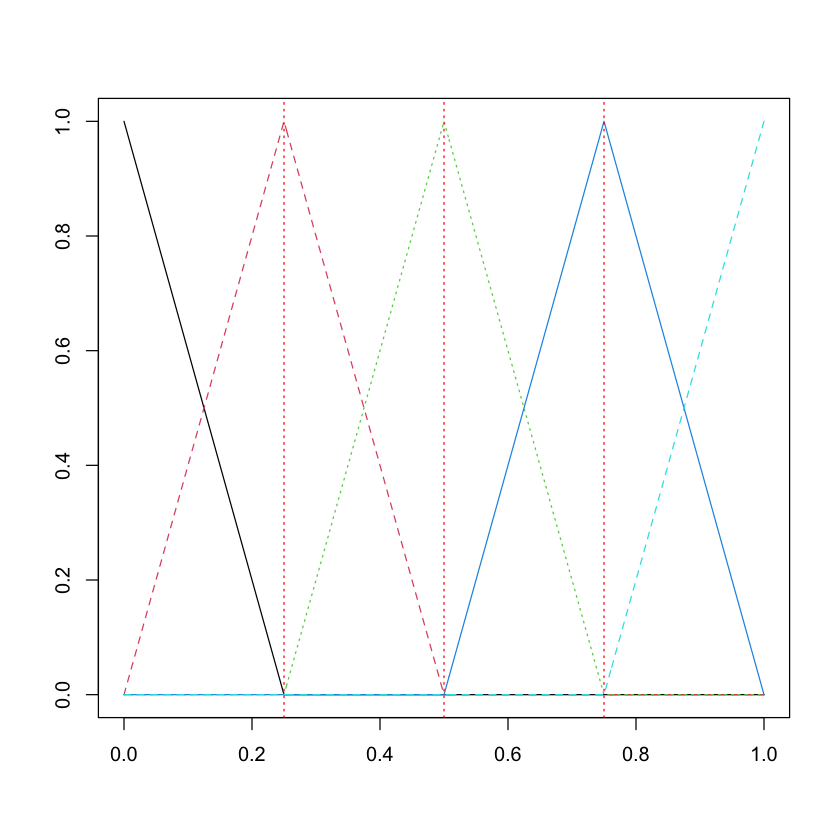

In [11]:
bspline.basis = create.bspline.basis(unitRng, nbasis=5, 
                                     norder=2, 
                                     breaks=seq(0, 1, length=5) )
plot(bspline.basis)

In [12]:
##
## Section 3.2 Fourier Series for Periodic Data and Functions
##

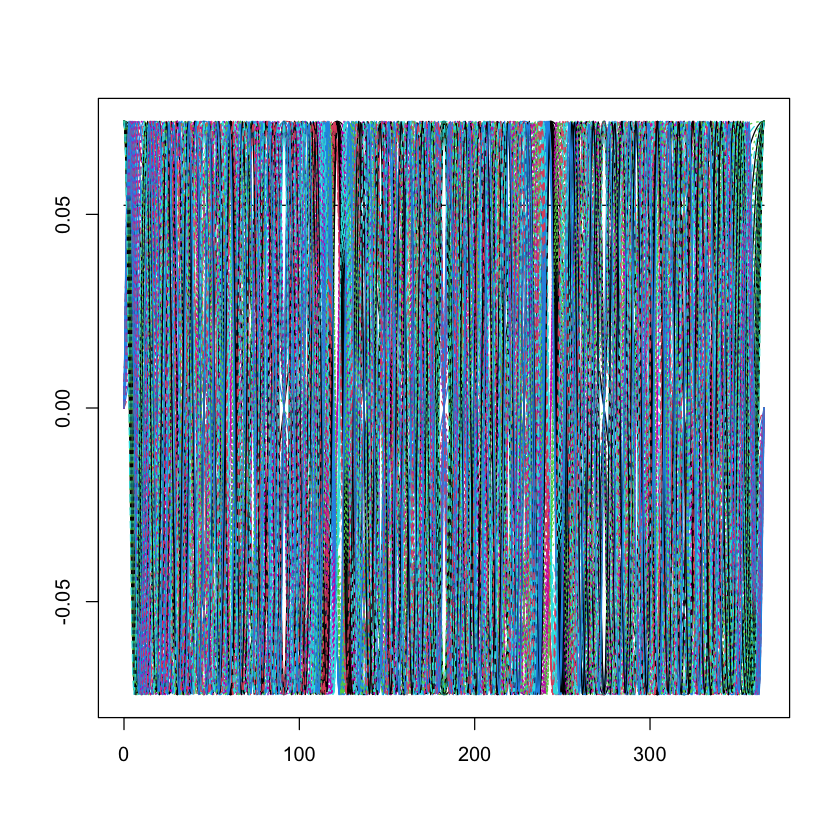

In [13]:
yearRng = c(0,365)

daybasis65 = create.fourier.basis(yearRng, 65)
plot(daybasis65)

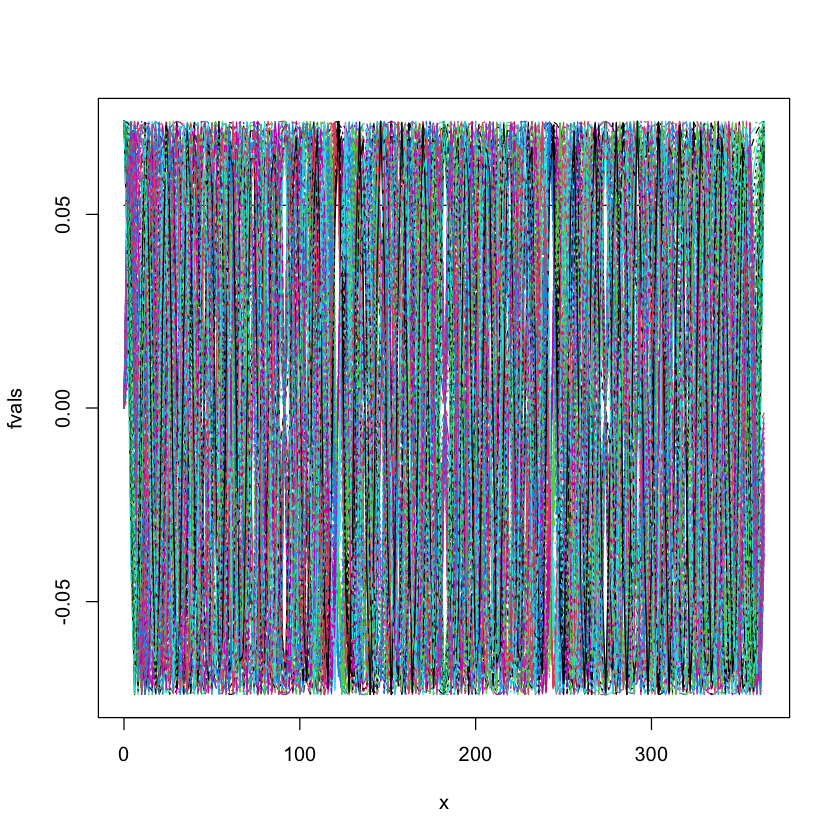

In [14]:
tt <- seq(0, 365, by = 2)
fvals <- eval.basis(tt, daybasis65)
matplot(tt,fvals,type='l')

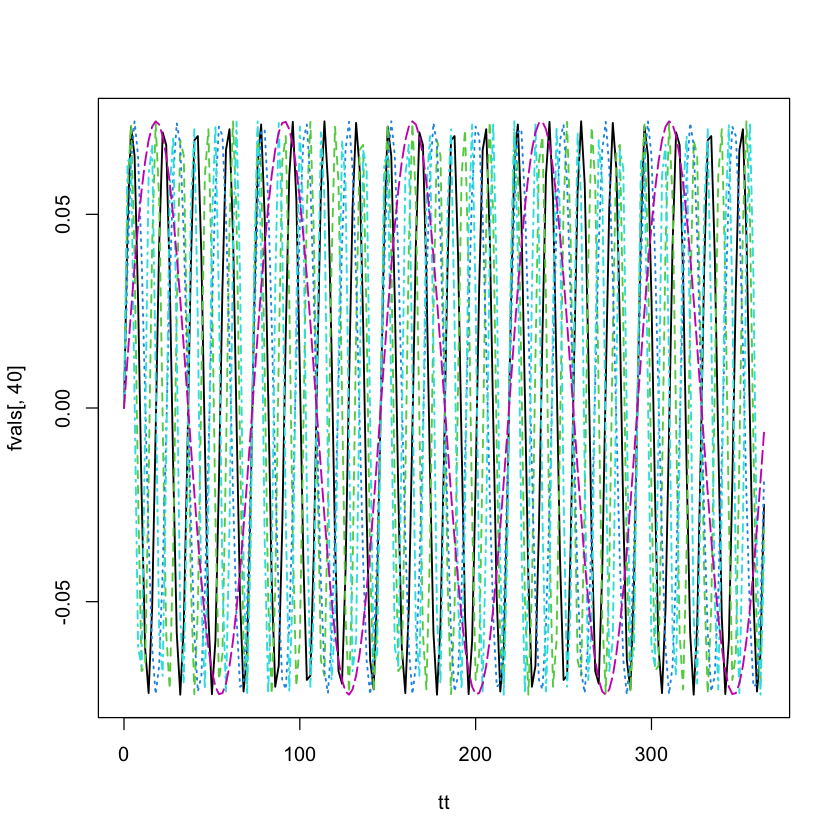

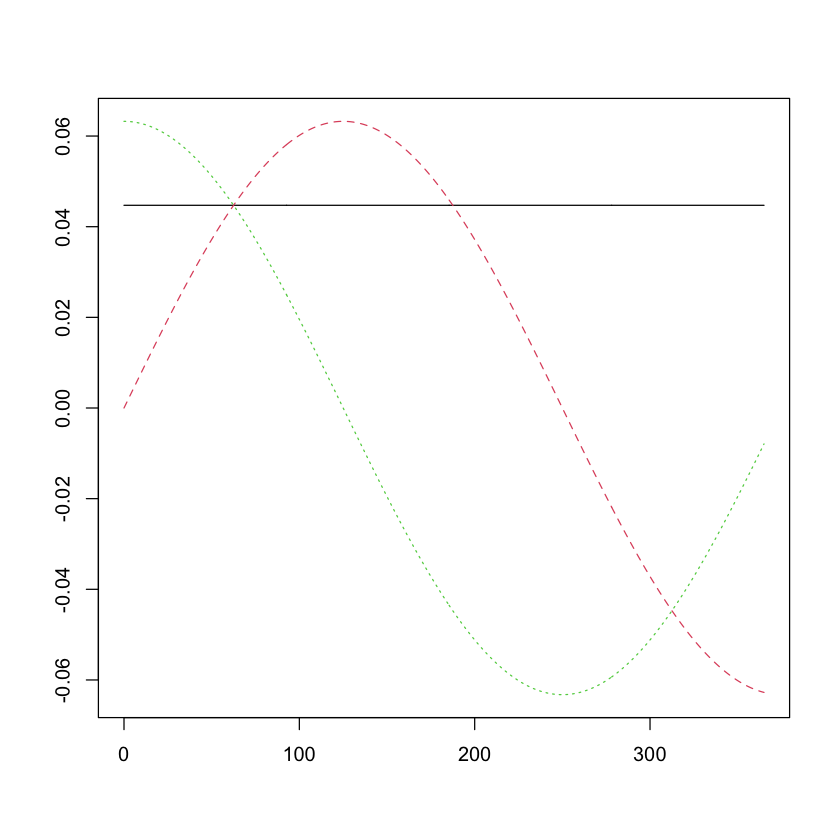

In [15]:
plot(tt,fvals[,40],type='l',lwd=1.5, lty=1)
lines(tt,fvals[,50],col=3,lwd=1.5, lty=2)
lines(tt,fvals[,30],col=4,lwd=1.5, lty=3)
lines(tt,fvals[,60],col=5,lwd=1.5, lty=4)
lines(tt,fvals[,10],col=6,lwd=1.5, lty=5)

T_size        = 500
daybasis.T = create.fourier.basis(yearRng, 3, period=T_size)
plot(daybasis.T)

In [16]:
# dropindthat contains a vector of indices 
# of basis functions to remove from the final series
zerobasis  = create.fourier.basis(yearRng, 65, dropind=1)
all.equal(zerobasis, daybasis65)
str(zerobasis)
str(daybasis65)

[1] "Component “dropind”: Numeric: lengths (1, 0) differ"

List of 10
 $ call       : language basisfd(type = type, rangeval = rangeval, nbasis = nbasis, params = params,      dropind = dropind, quadvals = qu| __truncated__
 $ type       : chr "fourier"
 $ rangeval   : num [1:2] 0 365
 $ nbasis     : num 65
 $ params     : num 365
 $ dropind    : num 1
 $ quadvals   : NULL
 $ values     : list()
 $ basisvalues: list()
 $ names      : chr [1:65] "const" "sin1" "cos1" "sin2" ...
 - attr(*, "class")= chr "basisfd"
List of 10
 $ call       : language basisfd(type = type, rangeval = rangeval, nbasis = nbasis, params = params,      dropind = dropind, quadvals = qu| __truncated__
 $ type       : chr "fourier"
 $ rangeval   : num [1:2] 0 365
 $ nbasis     : num 65
 $ params     : num 365
 $ dropind    : num(0) 
 $ quadvals   : NULL
 $ values     : list()
 $ basisvalues: list()
 $ names      : chr [1:65] "const" "sin1" "cos1" "sin2" ...
 - attr(*, "class")= chr "basisfd"


Warning message in any(diff(dropind)):
“coercing argument of type 'double' to logical”
Warning message in any(diff(dropind)):
“coercing argument of type 'double' to logical”


List of 10
 $ call       : language basisfd(type = type, rangeval = rangeval, nbasis = nbasis, params = params,      dropind = dropind, quadvals = qu| __truncated__
 $ type       : chr "fourier"
 $ rangeval   : num [1:2] 0 365
 $ nbasis     : num 65
 $ params     : num 365
 $ dropind    : num [1:32] 3 5 7 9 11 13 15 17 19 21 ...
 $ quadvals   : NULL
 $ values     : list()
 $ basisvalues: list()
 $ names      : chr [1:65] "const" "sin1" "cos1" "sin2" ...
 - attr(*, "class")= chr "basisfd"
List of 10
 $ call       : language basisfd(type = type, rangeval = rangeval, nbasis = nbasis, params = params,      dropind = dropind, quadvals = qu| __truncated__
 $ type       : chr "fourier"
 $ rangeval   : num [1:2] 0 365
 $ nbasis     : num 65
 $ params     : num 365
 $ dropind    : num [1:32] 2 4 6 8 10 12 14 16 18 20 ...
 $ quadvals   : NULL
 $ values     : list()
 $ basisvalues: list()
 $ names      : chr [1:65] "const" "sin1" "cos1" "sin2" ...
 - attr(*, "class")= chr "basisfd"


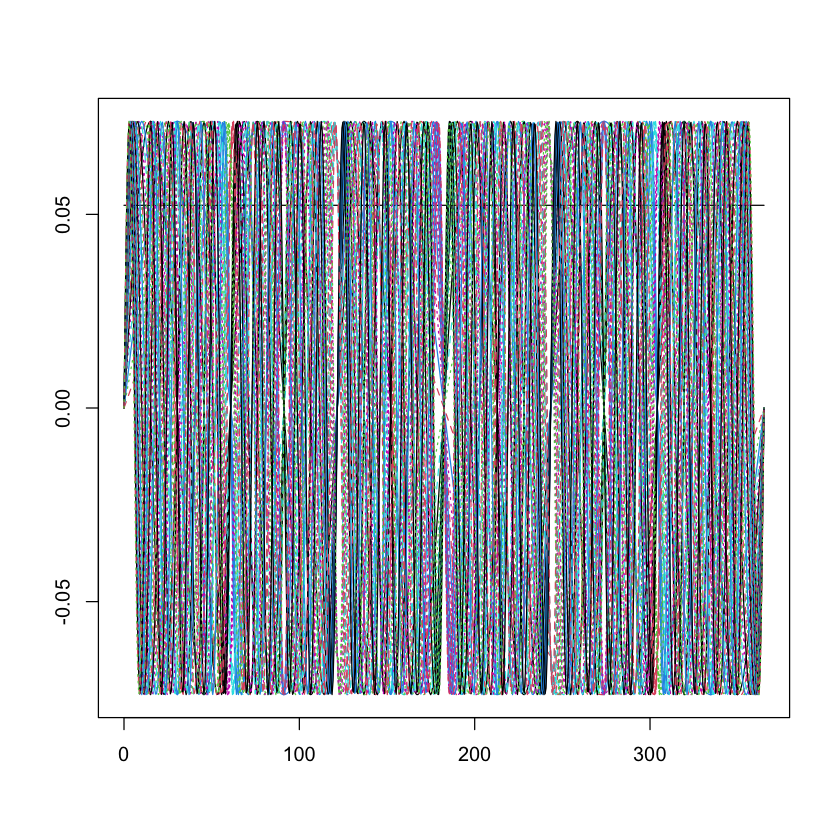

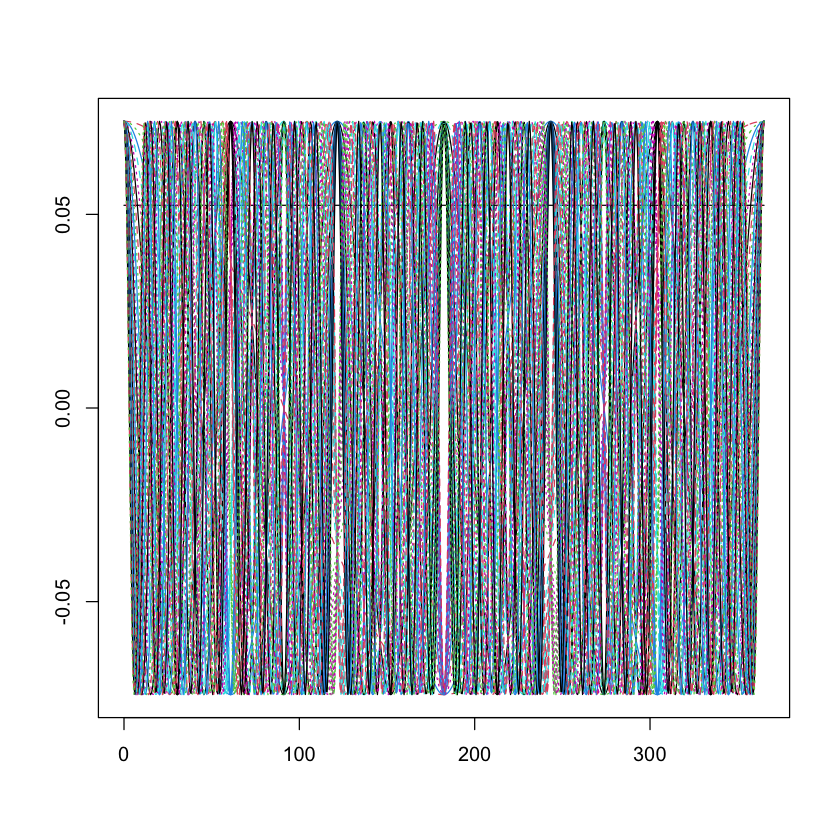

In [17]:
sinbasis <- create.fourier.basis(yearRng, 65, dropind=seq(3,65,by=2))
cosbasis <- create.fourier.basis(yearRng, 65, dropind=seq(2,65,by=2))
str(sinbasis)
str(cosbasis)
plot(sinbasis)
plot(cosbasis)

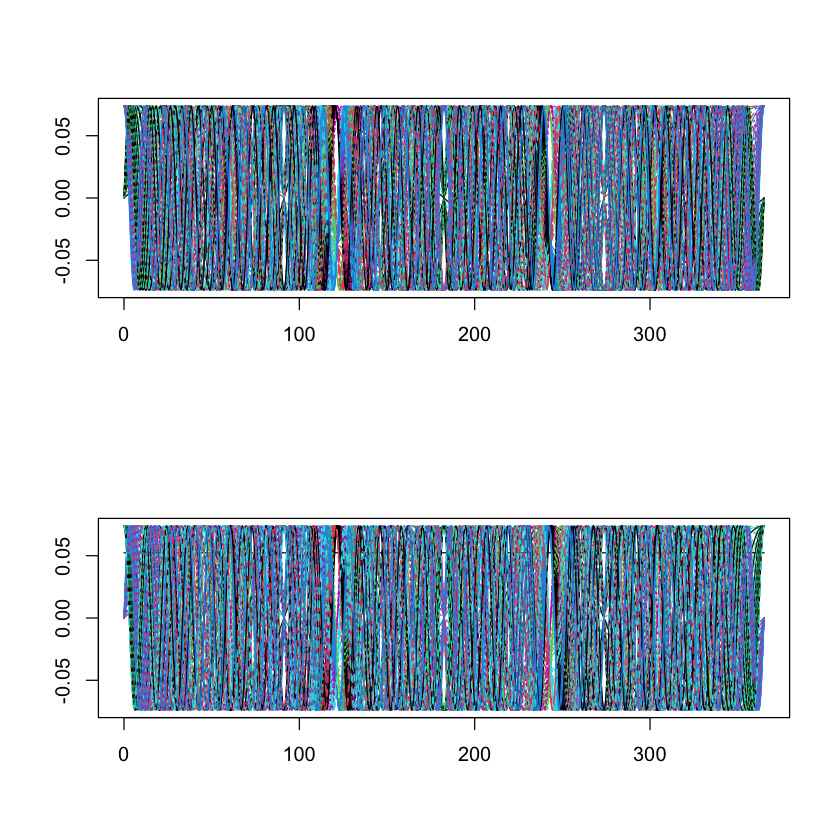

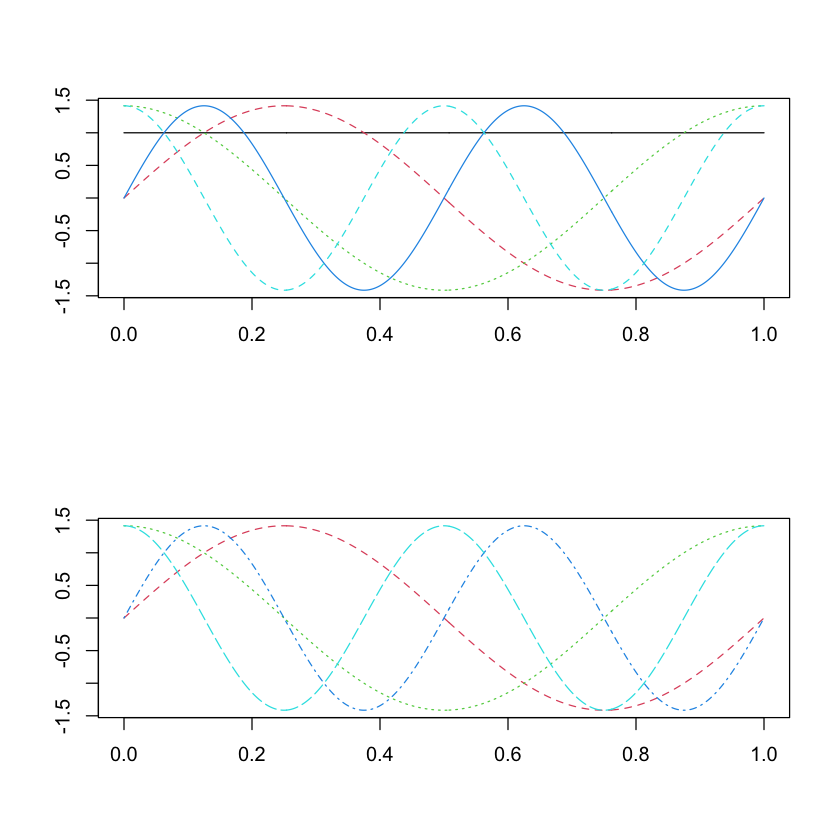

In [18]:
opar <- par(mfrow=c(2,1))
plot(zerobasis)
plot(daybasis65)
par(opar)


f.ex1 <- create.fourier.basis(unitRng, 5)
f.ex2 <- create.fourier.basis(unitRng, nbasis=5, dropind = 1)

opar <- par(mfrow=c(2,1))
plot(f.ex1)
plot(f.ex2, col=2:5, lty=2:5)
par(opar)

In [19]:
##
## Section 3.3 Spline series for Non-periodic Data and Functions
##

In [23]:
#  section 3.3.3 Examples

#  order 4 spline, one interior knot

bspline4 = create.bspline.basis(breaks=c(0, .5, 1))

# knots and knots.fd do not work for the moment
knots.fd(bspline4, interior=FALSE)
?knots.fd

ERROR: Error in knots.fd(bspline4, interior = FALSE): could not find function "knots.fd"


In [24]:
# number of basis functions = order + number of interior knots.
# if we define a function over [0,1] with a single interior break point at 0.5 with cubic 
# splinebasis (order 4), then the knots are (0, 0, 0, 0, 0.5, 1, 1, 1, 1)
nord <- norder(bspline4)
rng <- bspline4$rangeval 
int <- bspline4$params
nord; rng; int
allKnots <- c(rep(rng[1], nord), int, rep(rng[2], nord))
allKnots

[1] 4

[1] 0 1

[1] 0.5

[1] 0.0 0.0 0.0 0.0 0.5 1.0 1.0 1.0 1.0

[1] 0.5

[1] 0.0 0.0 0.0 0.0 0.5 1.0 1.0 1.0 1.0

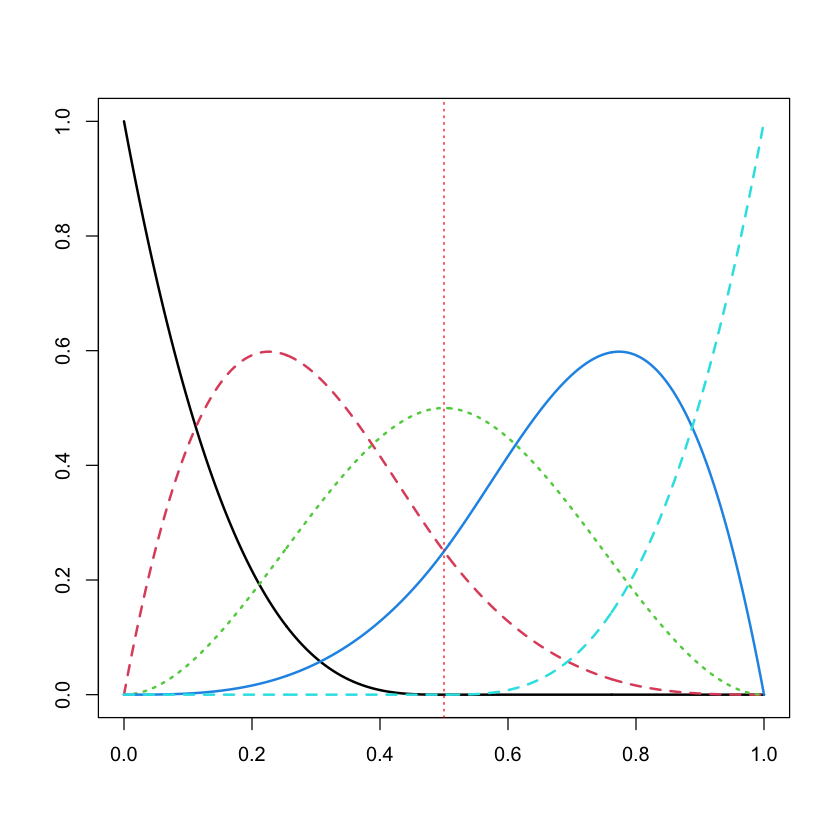

In [25]:
# we may write our own function for knots:
knots.fda <- function(Fn, interior=TRUE) {
  if(!class(bspline4) == "basisfd") stop("Object mus be of class basisfd")
  
  int <- Fn$params
  if(interior == TRUE) return(int)
  
  if(interior != TRUE) {
    nord <- norder(Fn)
    rng <- Fn$rangeval
    allKnots <- c(rep(rng[1], nord), int, rep(rng[2], nord))
    return(allKnots)
  }
}

knots.fda(bspline4, interior = TRUE)
knots.fda(bspline4, interior = FALSE)

plot(bspline4, lwd=2)

[1] 0.0 0.0 0.5 1.0 1.0

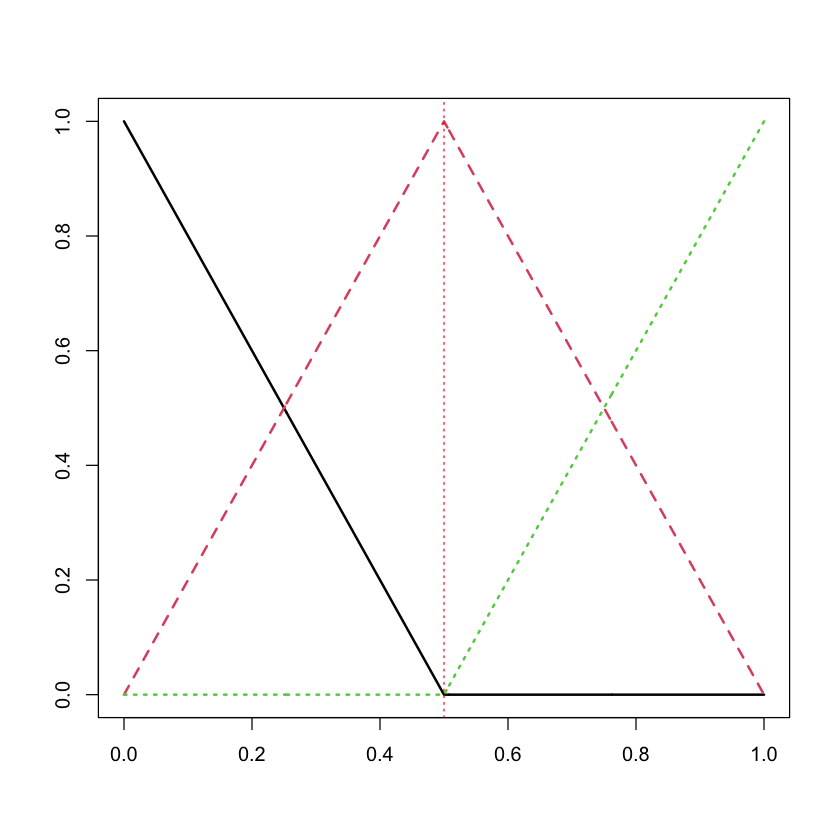

In [26]:
#  order 2 spline, one interiot knot

bspline2 = create.bspline.basis(breaks=c(0, .5, 1), norder=2)
knots.fda(bspline2, interior=FALSE)

plot(bspline2, lwd=2)

[1] 0.0 0.0 0.5 0.5 1.0 1.0

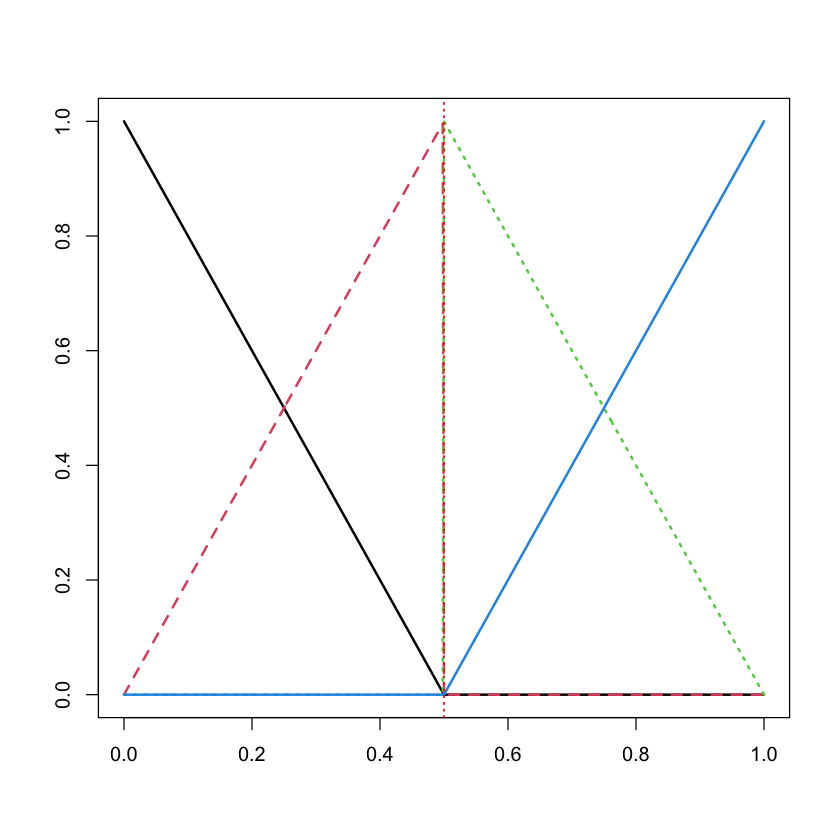

In [27]:
#  order 2 spline,  2 equal interior knots

bspline2.2 = create.bspline.basis(breaks=c(0, .5, .5, 1), norder=2)
knots.fda(bspline2.2, interior=FALSE)

plot(bspline2.2, lwd=2)

In [28]:
#  order 4 spline, 3 equal interior knots

bspline4.2 = create.bspline.basis(breaks=c(0, .5, .5, .5, 1), norder=2)
knots.fda(bspline4.3, interior=FALSE)

plot(bspline4.3, lwd=2)

ERROR: Error: object 'bspline4.3' not found


In [29]:
#  section 3.3.4 B-Splines

splinebasis = create.bspline.basis(c(0,10), 13)
norder(splinebasis)
knots.fda(splinebasis)

[1] 4

[1] 1 2 3 4 5 6 7 8 9

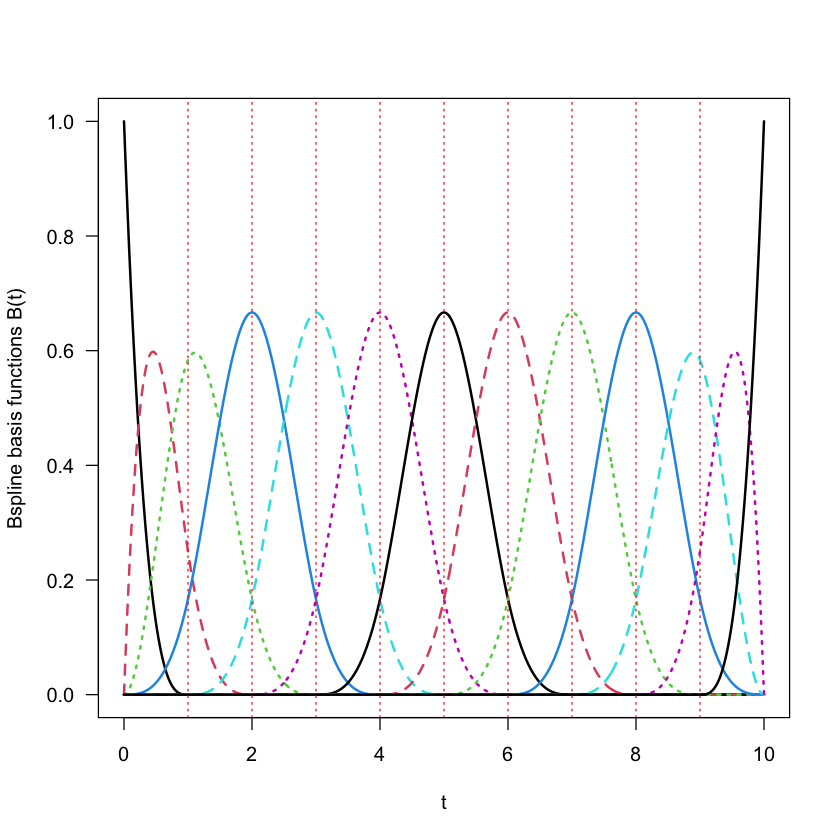

In [30]:
# Figure 3.1

plot(splinebasis, xlab='t', ylab='Bspline basis functions B(t)', 
     las=1, lwd=2)

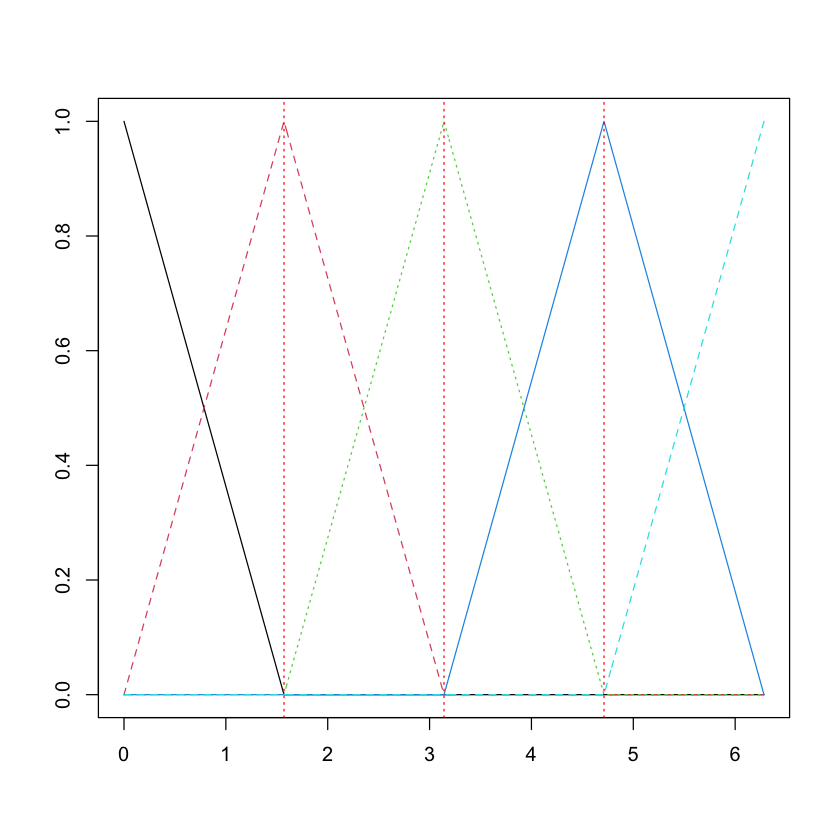

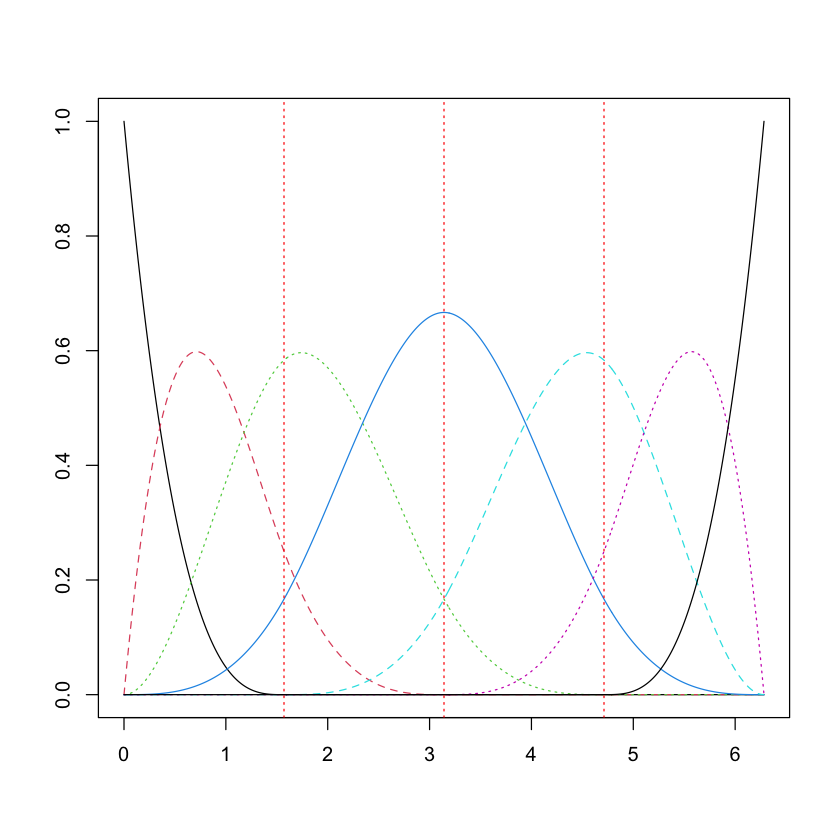

In [31]:
# Figure 3.2

#creat basis functions
basis2 = create.bspline.basis(c(0,2*pi), 5, 2)
basis3 = create.bspline.basis(c(0,2*pi), 6, 3)
basis4 = create.bspline.basis(c(0,2*pi), 7, 4)
plot(basis2)
plot(basis4)

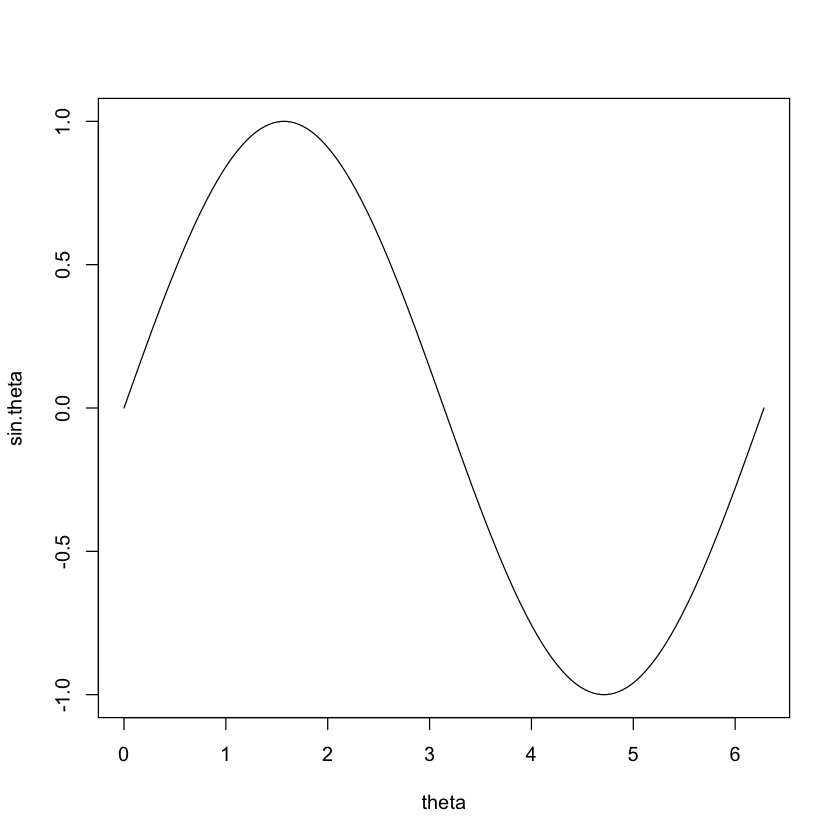

In [32]:
#simulate data
theta     = seq(0, 2*pi, length=201)
sin.theta = sin(theta)
plot(theta, sin.theta, type="l")

[1] "done"

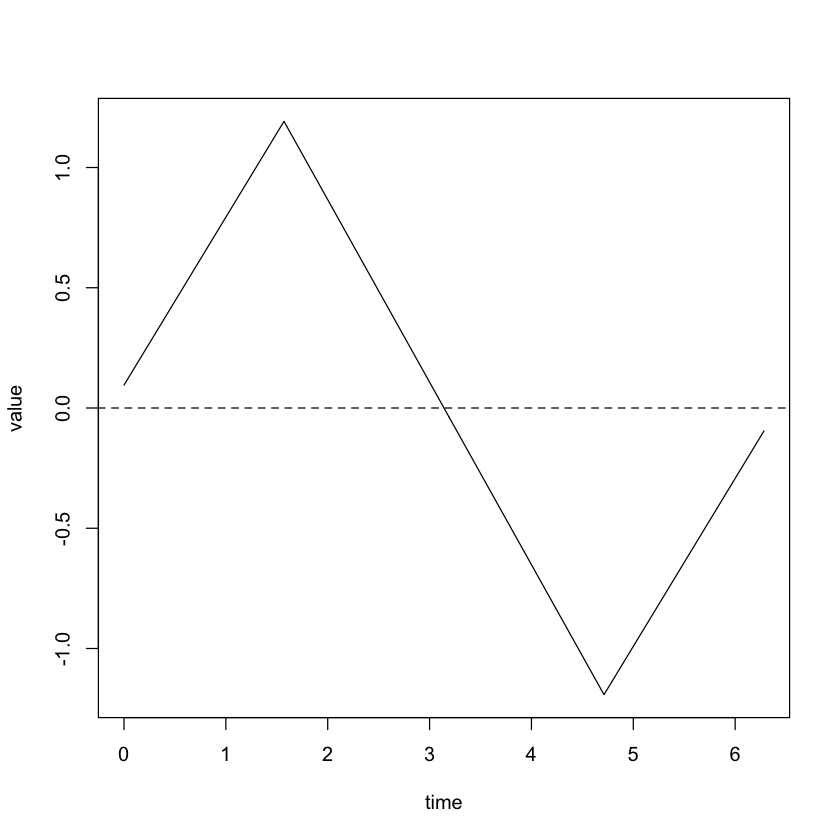

In [33]:
#create functional data from simulated data and basis functions
sin2 = Data2fd(theta, sin.theta, basis2)
sin3 = Data2fd(theta, sin.theta, basis3)
sin4 = Data2fd(theta, sin.theta, basis4)
plot(sin2)


0.09514333,0.09514333
0.11707926,0.11707926
0.13901518,0.13901518
0.16095110,0.16095110
0.18288703,0.18288703
0.20482295,0.20482295


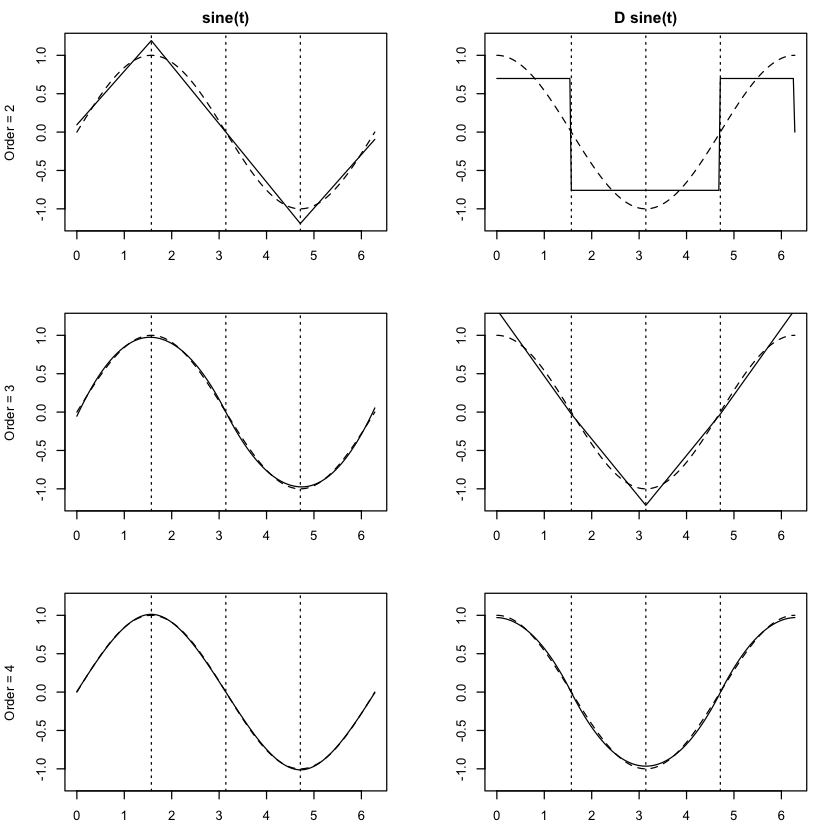

In [34]:
#evalute function values at certain points
sin2.theta = predict(sin2, theta)
sin2.theta2 <- eval.fd(theta, sin2)
head(cbind(sin2.theta, sin2.theta2))

sin3.theta = predict(sin3, theta)
sin4.theta = predict(sin4, theta)


sinRng = range(sin2.theta)
pi3    = ((1:3)*pi/2)

op = par(mfrow=c(3,2), mar=c(3,4,2,2)+.1)

plot(theta, sin2.theta, type='l', ylim=sinRng, xlab='', ylab='Order = 2',
     main='sine(t)' )
lines(theta, sin.theta, lty='dashed')
abline(v=pi3, lty='dotted')

Dsin2.theta = predict(sin2, theta, 1) # first derivative
plot(theta, Dsin2.theta, type='l', ylim=sinRng, xlab='', ylab='',
     main='D sine(t)')
lines(theta, cos(theta), lty='dashed')
abline(v=pi3, lty='dotted')

plot(theta, sin3.theta, type='l', ylim=sinRng, xlab='', ylab='Order = 3')
lines(theta, sin.theta, lty='dashed')
abline(v=pi3, lty='dotted')

Dsin3.theta = predict(sin3, theta, 1)
plot(theta, Dsin3.theta, type='l', ylim=sinRng, xlab='', ylab='')
lines(theta, cos(theta), lty='dashed')
abline(v=pi3, lty='dotted')

plot(theta, sin4.theta, type='l', ylim=sinRng, xlab='t', ylab='Order = 4')
lines(theta, sin.theta, lty='dashed')
abline(v=pi3, lty='dotted')

Dsin4.theta <- predict(sin4, theta, 1)
plot(theta, Dsin4.theta, type='l', ylim=sinRng, xlab='t', ylab='')
lines(theta, cos(theta), lty='dashed')
abline(v=pi3, lty='dotted')

par(op)

[1] 0.0 0.0 0.0 0.0 0.7 1.0 1.0 1.0 1.0

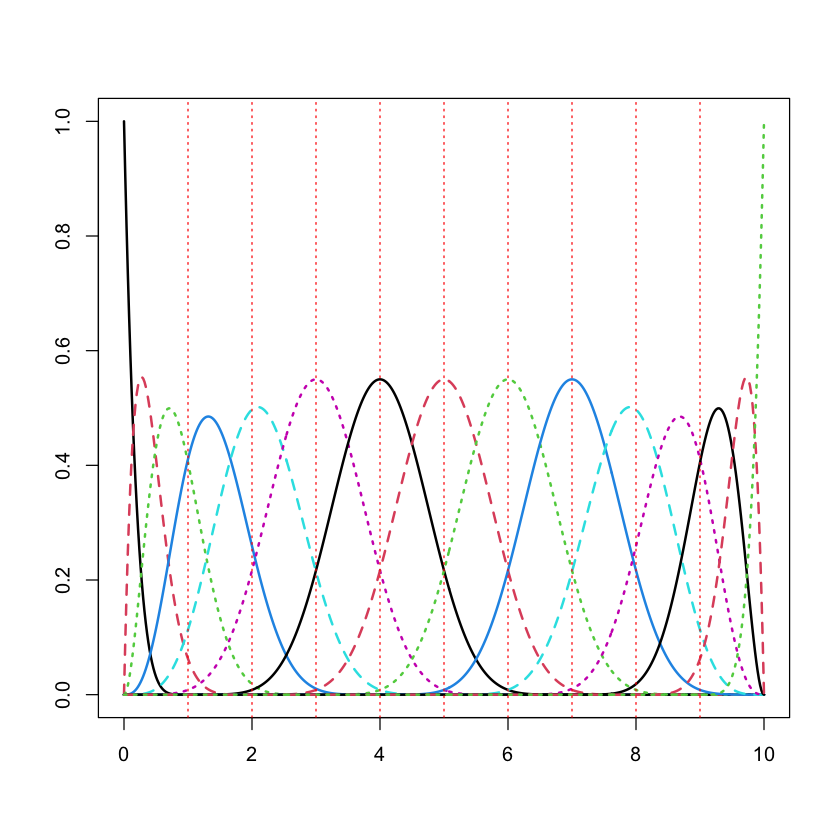

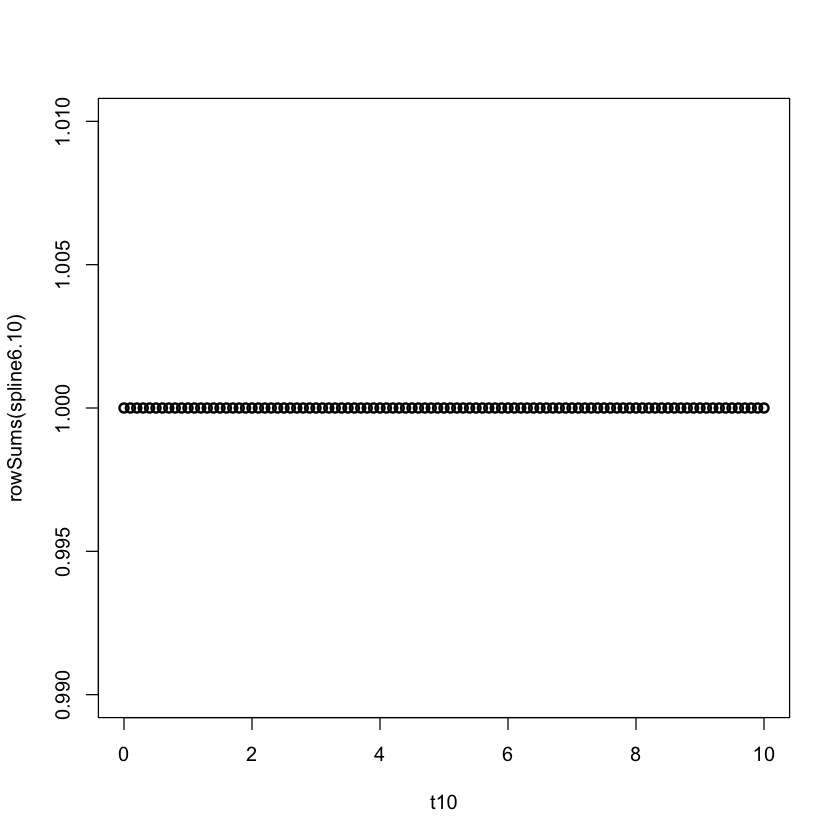

In [36]:
#  order 6 spline with equally spaced knots

splinebasis6 = create.bspline.basis(c(0,10), 15, 6)
plot(splinebasis6, lwd=2)


#  order 4 spline with knots not equally spaced

spline.unequal.knots = create.bspline.basis(breaks=c(0, .7, 1))
knots.fda(spline.unequal.knots, interior=FALSE)

#  plot sum of basis function values (all equal to 1)

t10 = seq(0, 10, .1)
spline6.10 = predict(splinebasis6, t10)
plot(t10, rowSums(spline6.10), lwd=2)

[1] TRUE

[1] TRUE

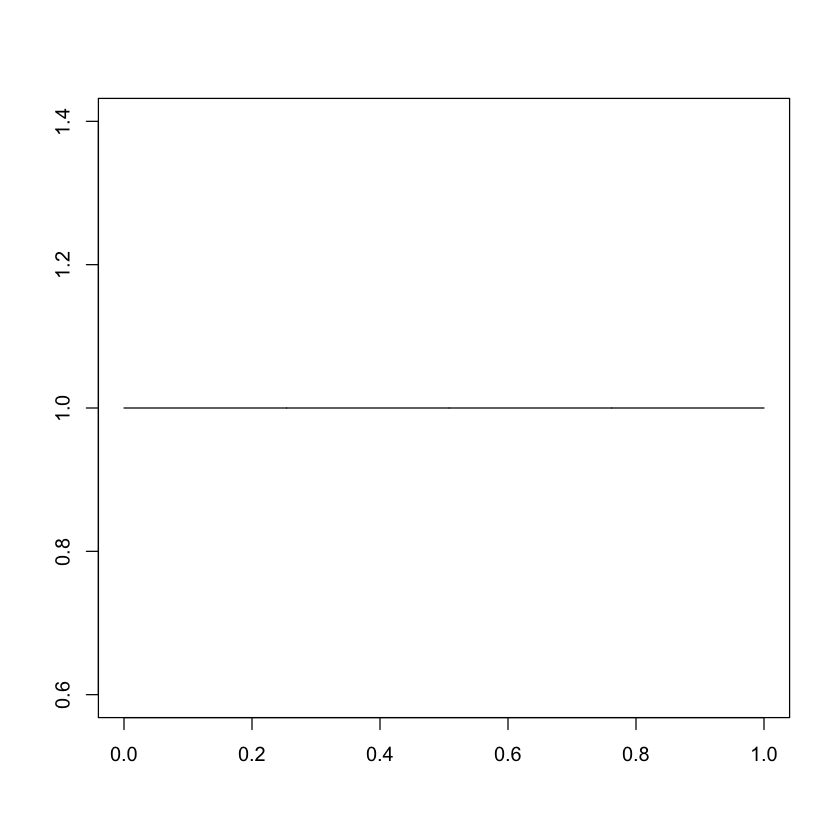

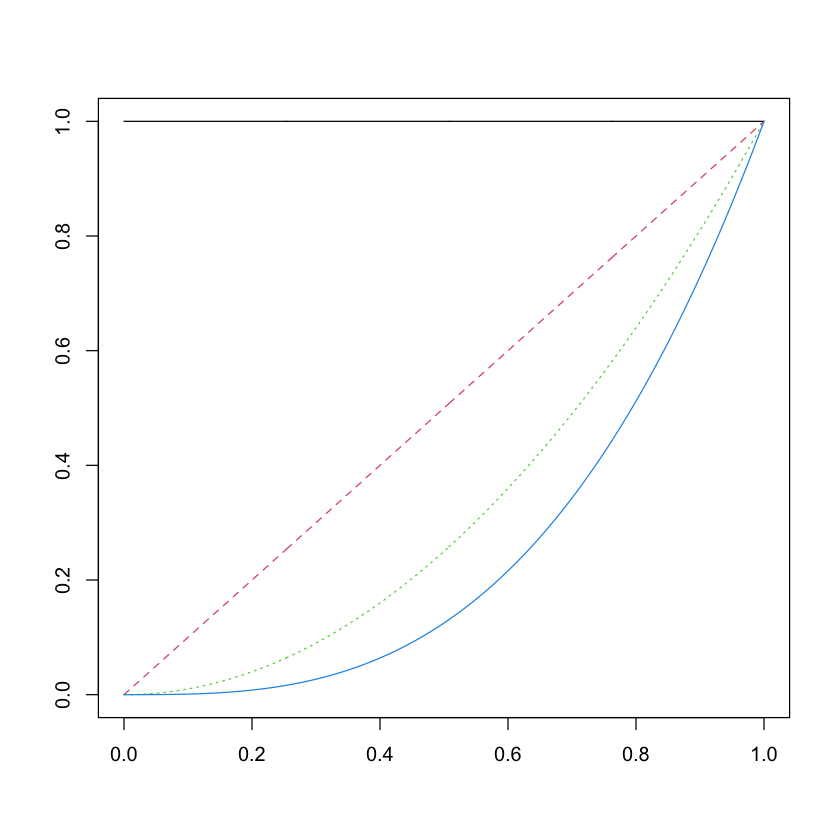

In [37]:
##
## Section 3.4 Constant, Monomial and Other Bases
##

conbasis = create.constant.basis(c(0,1))
conb     = create.constant.basis()
all.equal(conbasis, conb)
plot(conbasis)

monbasis = create.monomial.basis(c(0,1), 4)
monb     = create.monomial.basis(nbasis=4)
all.equal(monbasis, monb)
plot(monbasis)

[1] *       ==      norder  plot    predict summary
see '?methods' for accessing help and source code

$call
basisfd(type = type, rangeval = rangeval, nbasis = nbasis, params = params, 
    dropind = dropind, quadvals = quadvals, values = values, 
    basisvalues = basisvalues)

$type
[1] "monom"

$rangeval
[1] 0 1

$nbasis
[1] 4

$params
[1] 0 1 2 3

$dropind
NULL

$quadvals
NULL

$values
list()

$basisvalues
list()

$names
[1] "monomial0" "monomial1" "monomial2" "monomial3"

attr(,"class")
[1] "basisfd"

Basis object:

  Type:   monom 

  Range:  0  to  1 

  Number of basis functions:  4 


[1] TRUE

[1] TRUE

[1] TRUE

[1] 0 1 2 3

[1] 1
[1] 2
[1] 2
[1] 1
[1] 3
[1] 4
[1] 3
[1] 4
[1] 6
[1] 5


[1] TRUE

[1] 1
[1] 2
[1] 2
[1] 1
[1] 3
[1] 4
[1] 3
[1] 4
[1] 6
[1] 5


[1] TRUE

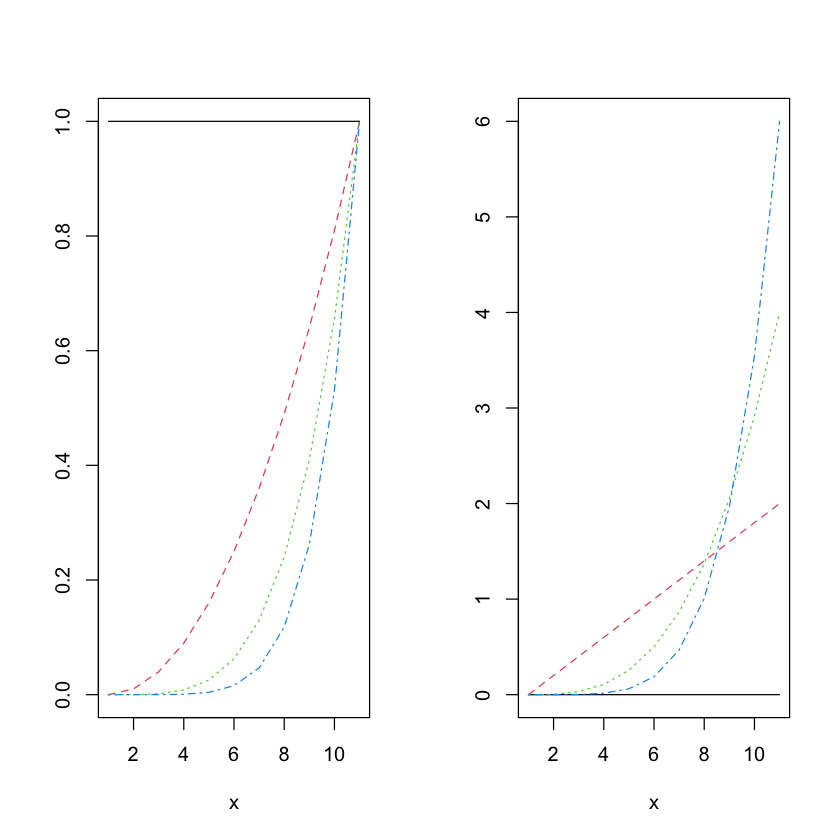

In [38]:
##
## Section 3.5 Methods for Functional Basis Objects
##

methods(class='basisfd')

print(monb)

summary(monb)

monbasis == monb

is(monb, 'basisfd')
inherits(monb, 'basisfd')

monb$params
monb$params = 2*(0:3)

t.1        = seq(0, 1, .1)
monbmat.1  = eval.basis(t.1, monb)
Dmonbmat.1 = eval.basis(t.1, monb, 1)

opar <- par(mfrow=c(1,2))
matplot(monbmat.1, type="l")
matplot(Dmonbmat.1, type="l")
par(opar)

monbmat.1. = predict(monb, t.1)
all.equal(monbmat.1, monbmat.1.)

Dmonbmat.1. = predict(monb, t.1, 1)
all.equal(Dmonbmat.1, Dmonbmat.1.)
